In [1]:
from scr.qsvdd_core.circuits import QSVDDCircuit
import numpy as np
from qiskit import transpile, QuantumCircuit
from qclib.util import get_cnot_count

In [11]:
n_qubits = 5
amplitudes = np.random.rand(32)
amplitudes /= np.linalg.norm(amplitudes)
# amplitudes = np.pad(amplitudes, (0, 32 - len(amplitudes)), mode='constant')
params = np.random.rand(9*n_qubits)

In [16]:
q_circuit = QSVDDCircuit(n_qubits)

methods_map = {
    "UCGE": "ucge",
    "Qiskit Native": "qiskit",
    "DCSP": "dcsp",
    "BAA LowRank": "baa_lowrank",
    "BDSP": "bdsp",
    "Isometry": "isometry"
}

original_circuits = {
    name: q_circuit.feature_mapping(amplitudes, method=method)
    for name, method in methods_map.items()
}

basis_gates = ['u', 'cx']
transpiled_circuits = {
    name: transpile(qc, basis_gates=basis_gates)
    for name, qc in original_circuits.items()
}

header = f"{' Quantum Feature Mapping Benchmarks ':=^60}"
print(f"\n{header}")
print(f"{'Method Strategy':<25} | {'CNOT Count':>12} | {'Circuit Depth':>14}")
print("-" * 60)

for name, qc in transpiled_circuits.items():
    cnot_count = qc.count_ops().get('cx', 0)
    depth = qc.depth()

    print(f"{name:<25} | {cnot_count:>12} | {depth:>12}")

print("=" * 60)


============ Quantum Feature Mapping Benchmarks ============
Method Strategy           |   CNOT Count |  Circuit Depth
------------------------------------------------------------
UCGE                      |           26 |           53
Qiskit Native             |           26 |           53
DCSP                      |          182 |           93
BAA LowRank               |           21 |           34
BDSP                      |           94 |           74
Isometry                  |           26 |           53


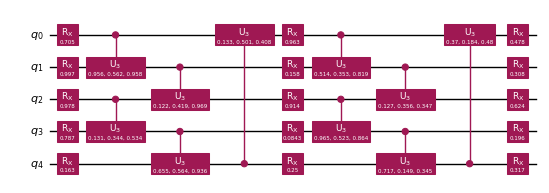

In [13]:
qc_ansatz = q_circuit.ansatz(params)
qc_ansatz.draw('mpl', scale=.5, fold=-1)

the ansatz_circuit has 20 CNOTs and depth of 21


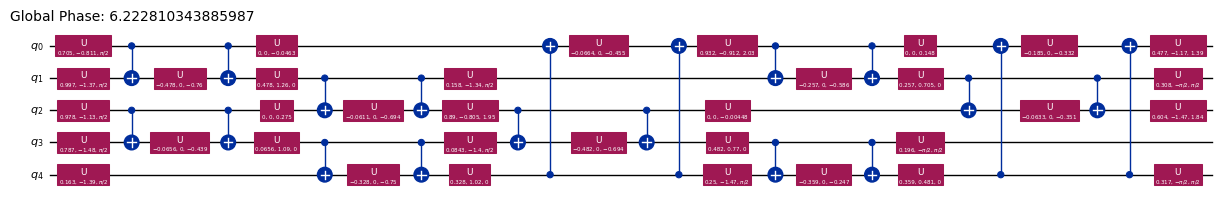

In [14]:
qc_ansatz_transpiled= transpile(qc_ansatz, basis_gates=['u', 'cx'])

print(
    'the ansatz_circuit has %d CNOTs and depth of %d'
    %(get_cnot_count(qc_ansatz_transpiled), qc_ansatz_transpiled.depth())
)

qc_ansatz_transpiled.draw('mpl', scale=.5, fold=-1)